In [1]:
!python -c "import monai" || pip install -q "monai-weekly[pillow, tqdm]"
!python -c "import matplotlib" || pip install -q matplotlib
%matplotlib inline

In [2]:
import os
import shutil
import tempfile
import matplotlib.pyplot as plt
import PIL
import torch
from torch.utils.tensorboard import SummaryWriter
import numpy as np
from sklearn.metrics import classification_report

from monai.apps import download_and_extract
from monai.config import print_config
from monai.data import decollate_batch, DataLoader
from monai.metrics import ROCAUCMetric
from monai.networks.nets import DenseNet121
from monai.transforms import (
    Activations,
    EnsureChannelFirst,
    AsDiscrete,
    Compose,
    LoadImage,
    RandFlip,
    RandRotate,
    RandZoom,
    ScaleIntensity,
)
from monai.utils import set_determinism

print_config()

MONAI version: 1.5.2
Numpy version: 2.4.2
Pytorch version: 2.10.0
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /Users/<username>/Documents/CancerVision-1/.venv/lib/python3.13/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: NOT INSTALLED or UNKNOWN VERSION.
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.17.1
Pillow version: 12.1.1
Tensorboard version: 2.20.0
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.25.0
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: NOT INSTALLED or UNKNOWN VERSION.
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd ver

In [ ]:
import os
from pathlib import Path
#fjern models i dataset

def find_project_root() -> Path:
    """Finn prosjektrot ved å lete etter pyproject.toml eller .git oppover i mappehierarkiet"""
    current = Path(os.getcwd())
    for parent in [current, *current.parents]:
        if (parent / "pyproject.toml").exists() or (parent / ".git").exists():
            return parent
    raise FileNotFoundError("Fant ikke prosjektrot — ingen pyproject.toml eller .git funnet")

PROJ_ROOT = find_project_root()
directory = PROJ_ROOT / "res"
data_dir = directory / "archive" / "NINS_Dataset" / "NINS_Dataset" / "models"
deleteModels = input(f"Do you want to delete the 'models' directory in {data_dir}? (y/n): ")
if deleteModels.lower() == 'y':
    if data_dir.exists() and data_dir.is_dir():
        shutil.rmtree(data_dir)
        print(f"'models' directory deleted from {data_dir}.")
    else:
        print(f"'models' directory does not exist in {data_dir}.")
else:
    print("Skipping deletion of 'models' directory.")

'models' directory does not exist in /Users/fridakroken/Documents/CancerVision-1/res/archive/NINS_Dataset/NINS_Dataset/models.


In [ ]:
import shutil
# Fjern .ipynb_checkpoints-mapper i dataset

checkpoints = [
    data_dir / "demyelinating lesions" / ".ipynb_checkpoints",
    data_dir / "Encephalomalacia with gliotic change" / ".ipynb_checkpoints"
]

for path in checkpoints:
    if path.exists():
        shutil.rmtree(path)
        print(f"Slettet: {path}")
    else:
        print(f"Finnes ikke: {path}")

In [20]:
import os
from pathlib import Path

PROJ_ROOT = find_project_root()
directory = PROJ_ROOT / "res"
data_dir = directory / "archive" / "NINS_Dataset" / "NINS_Dataset"

# Verifiser at mappen finnes
assert data_dir.exists(), f"Fant ikke datasett på: {data_dir}"

# Scan klassebaserte undermapper
class_names = sorted([p.name for p in data_dir.iterdir() if p.is_dir()])
num_class = len(class_names)
print("Klasser funnet:", class_names)
print("Antall klasser:", num_class)


Klasser funnet: ['Brain Atrophy', 'Brain Infection', 'Brain Infection with abscess', 'Brain Tumor', 'Brain Tumor (Ependymoma)', 'Brain Tumor (Hemangioblastoma  Pleomorphic xanthroastrocytoma  metastasis)', 'Brain tumor (Astrocytoma Ganglioglioma)', 'Brain tumor (Dermoid cyst craniopharyngioma)', 'Brain tumor - Recurrenceremnant of previous lesion', 'Brain tumor operated with ventricular hemorrhage', 'Cerebral Hemorrhage', 'Cerebral abscess', 'Encephalomalacia with gliotic change', 'Glioma', 'Hemorrhagic collection', 'Ischemic change  demyelinating plaque', 'Left Retro-orbital Haemangioma', 'Leukoencephalopathy with subcortical cysts', 'Malformation (Chiari I)', 'Microvascular ischemic change', 'Mid triventricular hydrocephalus', 'NMOSD  ADEM', 'Normal', 'Obstructive Hydrocephalus', 'Post-operative Status with Small Hemorrhage', 'Postoperative encephalomalacia', 'Small Vessel Diease Demyelination', 'Stroke (Demyelination)', 'Stroke (Haemorrhage)', 'Stroke(infarct)', 'White Matter Diseas

In [21]:
image_files = [
    [
        f for f in (data_dir / class_name).iterdir()
        if f.suffix.lower() in (".jpg", ".jpeg") and f.is_file()  # ← legg til f.is_file()
    ]
    for class_name in class_names
]

In [22]:
set_determinism(seed=0)

In [23]:
class_names = sorted(x for x in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, x)))
num_class = len(class_names)
image_files = [
    [os.path.join(data_dir, class_names[i], x) for x in os.listdir(os.path.join(data_dir, class_names[i]))]
    for i in range(num_class)
]
num_each = [len(image_files[i]) for i in range(num_class)]
image_files_list = []
image_class = []
for i in range(num_class):
    image_files_list.extend([str(f) for f in image_files[i]])
    image_class.extend([i] * num_each[i])
num_total = len(image_class)
image_width, image_height = PIL.Image.open(image_files_list[0]).size

print(f"Total image count: {num_total}")
print(f"Image dimensions: {image_width} x {image_height}")
print(f"Label names: {class_names}")
print(f"Label counts: {num_each}")

Total image count: 5247
Image dimensions: 320 x 320
Label names: ['Brain Atrophy', 'Brain Infection', 'Brain Infection with abscess', 'Brain Tumor', 'Brain Tumor (Ependymoma)', 'Brain Tumor (Hemangioblastoma  Pleomorphic xanthroastrocytoma  metastasis)', 'Brain tumor (Astrocytoma Ganglioglioma)', 'Brain tumor (Dermoid cyst craniopharyngioma)', 'Brain tumor - Recurrenceremnant of previous lesion', 'Brain tumor operated with ventricular hemorrhage', 'Cerebral Hemorrhage', 'Cerebral abscess', 'Encephalomalacia with gliotic change', 'Glioma', 'Hemorrhagic collection', 'Ischemic change  demyelinating plaque', 'Left Retro-orbital Haemangioma', 'Leukoencephalopathy with subcortical cysts', 'Malformation (Chiari I)', 'Microvascular ischemic change', 'Mid triventricular hydrocephalus', 'NMOSD  ADEM', 'Normal', 'Obstructive Hydrocephalus', 'Post-operative Status with Small Hemorrhage', 'Postoperative encephalomalacia', 'Small Vessel Diease Demyelination', 'Stroke (Demyelination)', 'Stroke (Haemo

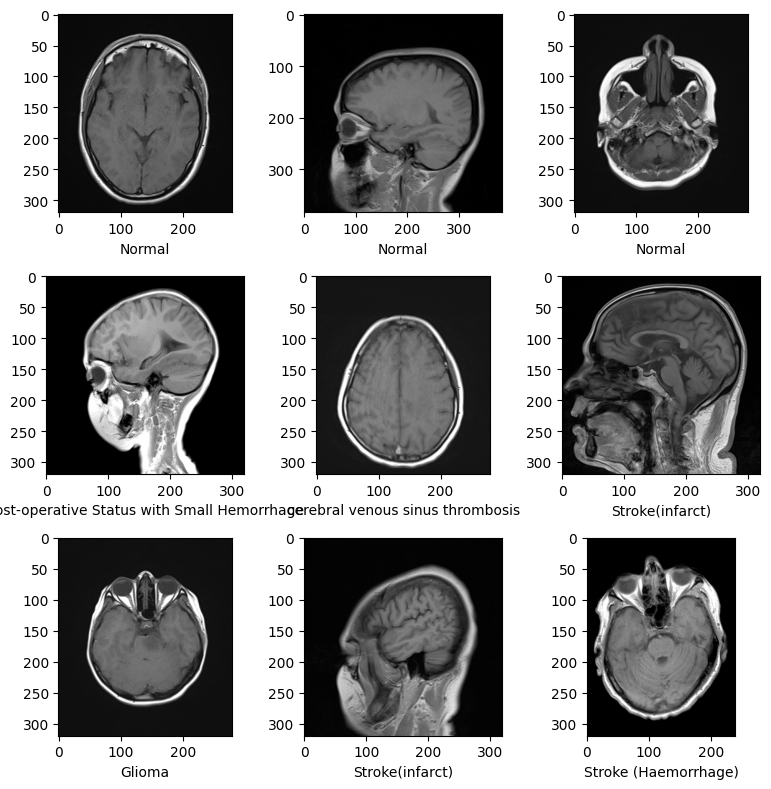

In [8]:
plt.subplots(3, 3, figsize=(8, 8))
for i, k in enumerate(np.random.randint(num_total, size=9)):
    im = PIL.Image.open(image_files_list[k])
    arr = np.array(im)
    plt.subplot(3, 3, i + 1)
    plt.xlabel(class_names[image_class[k]])
    plt.imshow(arr, cmap="gray", vmin=0, vmax=255)
plt.tight_layout()
plt.show()

In [24]:
val_frac = 0.1
test_frac = 0.1
length = len(image_files_list)
indices = np.arange(length)
np.random.shuffle(indices)

test_split = int(test_frac * length)
val_split = int(val_frac * length) + test_split
test_indices = indices[:test_split]
val_indices = indices[test_split:val_split]
train_indices = indices[val_split:]

train_x = [image_files_list[i] for i in train_indices]
train_y = [image_class[i] for i in train_indices]
val_x = [image_files_list[i] for i in val_indices]
val_y = [image_class[i] for i in val_indices]
test_x = [image_files_list[i] for i in test_indices]
test_y = [image_class[i] for i in test_indices]

print(f"Training count: {len(train_x)}, Validation count: " f"{len(val_x)}, Test count: {len(test_x)}")

Training count: 4199, Validation count: 524, Test count: 524


In [25]:
train_transforms = Compose(
    [
        LoadImage(image_only=True, reader="PILReader"),
        EnsureChannelFirst(),
        ScaleIntensity(),
        RandRotate(range_x=np.pi / 12, prob=0.5, keep_size=True),
        RandFlip(spatial_axis=0, prob=0.5),
        RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    ]
)

val_transforms = Compose([LoadImage(image_only=True, reader="PILReader"), EnsureChannelFirst(), ScaleIntensity()])

y_pred_trans = Compose([Activations(softmax=True)])
y_trans = Compose([AsDiscrete(to_onehot=num_class)])

In [26]:
from monai.transforms import (
    Compose, LoadImage, EnsureChannelFirst, ScaleIntensity,
    RandRotate, RandFlip, RandZoom, EnsureType, Lambda, Resize
)
from monai.data.image_reader import PILReader
import numpy as np

TARGET_SIZE = (64, 64)

to_grayscale = Lambda(func=lambda x: x.mean(dim=0, keepdim=True) if x.shape[0] == 3 else x)

train_transforms = Compose([
    LoadImage(image_only=True, reader=PILReader),
    EnsureChannelFirst(),
    to_grayscale,
    Resize(spatial_size=TARGET_SIZE),
    ScaleIntensity(),
    RandRotate(range_x=np.pi / 12, prob=0.5, keep_size=True),
    RandFlip(spatial_axis=0, prob=0.5),
    RandZoom(min_zoom=0.9, max_zoom=1.1, prob=0.5),
    EnsureType(),
])

val_transforms = Compose([
    LoadImage(image_only=True, reader=PILReader),
    EnsureChannelFirst(),
    to_grayscale,
    Resize(spatial_size=TARGET_SIZE),
    ScaleIntensity(),
    EnsureType(),
])

In [27]:
class MedNISTDataset(torch.utils.data.Dataset):
    def __init__(self, image_files, labels, transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        return self.transforms(self.image_files[index]), self.labels[index]


train_ds = MedNISTDataset(train_x, train_y, train_transforms)
train_loader = DataLoader(train_ds, batch_size=300, shuffle=True, num_workers=0)

val_ds = MedNISTDataset(val_x, val_y, val_transforms)
val_loader = DataLoader(val_ds, batch_size=300, num_workers=0)

test_ds = MedNISTDataset(test_x, test_y, val_transforms)
test_loader = DataLoader(test_ds, batch_size=300, num_workers=0)

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DenseNet121(spatial_dims=2, in_channels=1, out_channels=num_class).to(device)
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), 1e-5)
max_epochs = 4
val_interval = 1
auc_metric = ROCAUCMetric()

In [29]:
loader = LoadImage(image_only=True, reader=PILReader)

for i, path in enumerate(train_x):
    try:
        loader(path)
    except Exception as e:
        print(f"FEIL på index {i}: {path}")

In [32]:
best_metric = -1
best_metric_epoch = -1
epoch_loss_values = []
metric_values = []
writer = SummaryWriter()

for epoch in range(max_epochs):
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        print(f"{step}/{len(train_ds) // train_loader.batch_size}, " f"train_loss: {loss.item():.4f}")
        epoch_len = len(train_ds) // train_loader.batch_size
        writer.add_scalar("train_loss", loss.item(), epoch_len * epoch + step)
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            y_pred = torch.tensor([], dtype=torch.float32, device=device)
            y = torch.tensor([], dtype=torch.long, device=device)
            for val_data in val_loader:
                val_images, val_labels = (
                    val_data[0].to(device),
                    val_data[1].to(device),
                )
                y_pred = torch.cat([y_pred, model(val_images)], dim=0)
                y = torch.cat([y, val_labels], dim=0)
            y_onehot = [y_trans(i) for i in decollate_batch(y, detach=False)]
            y_pred_act = [y_pred_trans(i) for i in decollate_batch(y_pred)]
            auc_metric(y_pred_act, y_onehot)
            result = auc_metric.aggregate()
            auc_metric.reset()
            del y_pred_act, y_onehot
            metric_values.append(result)
            acc_value = torch.eq(y_pred.argmax(dim=1), y)
            acc_metric = acc_value.sum().item() / len(acc_value)
            if result > best_metric:
                best_metric = result
                best_metric_epoch = epoch + 1
                torch.save(model.state_dict(), os.path.join(root_dir, "best_metric_model.pth"))
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current AUC: {result:.4f}"
                f" current accuracy: {acc_metric:.4f}"
                f" best AUC: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
            writer.add_scalar("val_accuracy", acc_metric, epoch + 1)

print(f"train completed, best_metric: {best_metric:.4f} " f"at epoch: {best_metric_epoch}")
writer.close()

----------
epoch 1/4
1/13, train_loss: 3.6147
2/13, train_loss: 3.6084
3/13, train_loss: 3.5968
4/13, train_loss: 3.6094
5/13, train_loss: 3.5723
6/13, train_loss: 3.5609
7/13, train_loss: 3.5664
8/13, train_loss: 3.5684
9/13, train_loss: 3.5562
10/13, train_loss: 3.5547
11/13, train_loss: 3.5560
12/13, train_loss: 3.5390
13/13, train_loss: 3.5628
14/13, train_loss: 3.5384
epoch 1 average loss: 3.5717


NameError: name 'root_dir' is not defined